In [ ]:
from src.data_loader import load_data
from src.preprocess import prepare_data, print_vectorized_sample
from src.ML.train_NN import train_model, print_NN_input_sample, TextClassifier, DeepTextClassifier
from src.predict import predict_single_text
from src.analysis import  intra_category_similarity
from src.plotting import plot_confusion_matrix, plot_learning_curve, plot_metrics_bar_chart
from src.ML.train_svm import train_SVM
from src.ML.train_rf import train_random_forest

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
plt.rcParams["figure.figsize"] = (3,2)


Training of Neural Network models with different architectures on Ecommerce text Classification dataset, with input data processed with TF-IDF vectorizer and Word2Vec and MiniLM embedders.

In [2]:
# dataset structure:
# samples: 50 425
# categories: 4 (Househols, Electronics, Books, Clothing & Accessories)
# percentage: household: 38%, books: 24%, electronics: 21%, clothing & accessories: 17%

print("--- 1. Loading and Preparing Data ---")
df = load_data("/home/xkubanova_126831/bakalarka/e_com_dataset/data/ecommerceDataset.csv")


--- 1. Loading and Preparing Data ---
Dataset shape: (50425, 2)

Categories samples:

Books:
  Inner Engineering: A Yogi's Guide to Joy About the Author Sadhguru Jaggi VasudevSADHGURU is a yogi, mystic, and visionary who established the Isha Foundation, a nonprofit dedicated to the cultivation of human potential. He belongs to no particular tradition, and his scientific methods for self-transformation have universal appeal. Sadhguru has been an in?uential voice at global forums including th...

Clothing & Accessories:
  Woopower 36M Pink for 024M Baby Trouser Top Sets3Pcs Boy Girl Hooded Topsstriped Pantshairband Outfits36Mpink Size name36m colourpink description100 brand new and type children setgender unisexfor season autumn springcoloroptional pink greensize table 7080 90 100cminchsize tops length bust pants length age70 32 1260 46 1811 37 1457 36m80 34 1339 48 1890 39 1535 612m90 36 1417 52 2047 41 1614 1218m...

Electronics:
  Dell 19.5V-3.34AMP 65W Laptop Adapter (Without power C

Simple Feed Forward NN
Class weights: tensor([1.0665, 1.4538, 1.1869, 0.6528])
Test accuracy: 0.9737
                        precision    recall  f1-score   support

                 Books     0.9782    0.9691    0.9737      2364
Clothing & Accessories     0.9771    0.9844    0.9808      1734
           Electronics     0.9671    0.9685    0.9678      2124
             Household     0.9731    0.9746    0.9739      3863

              accuracy                         0.9737     10085
             macro avg     0.9739    0.9742    0.9740     10085
          weighted avg     0.9737    0.9737    0.9737     10085

Test accuracy: 0.9737


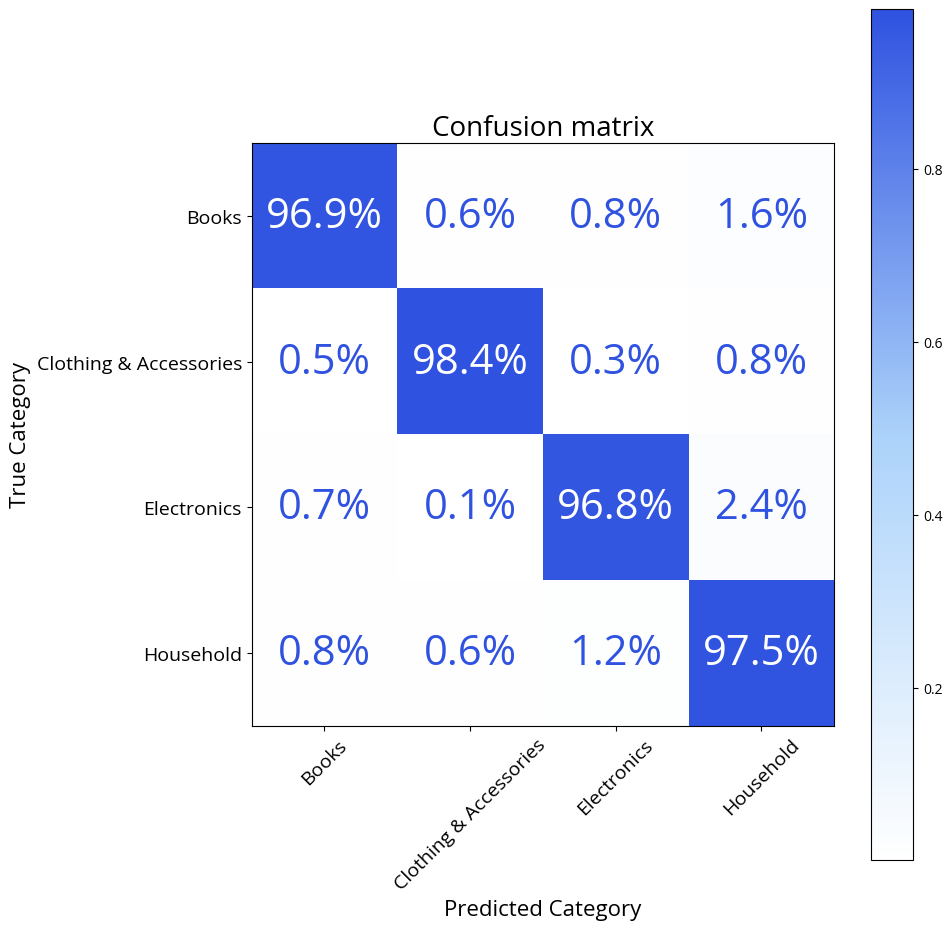

<Figure size 300x200 with 0 Axes>

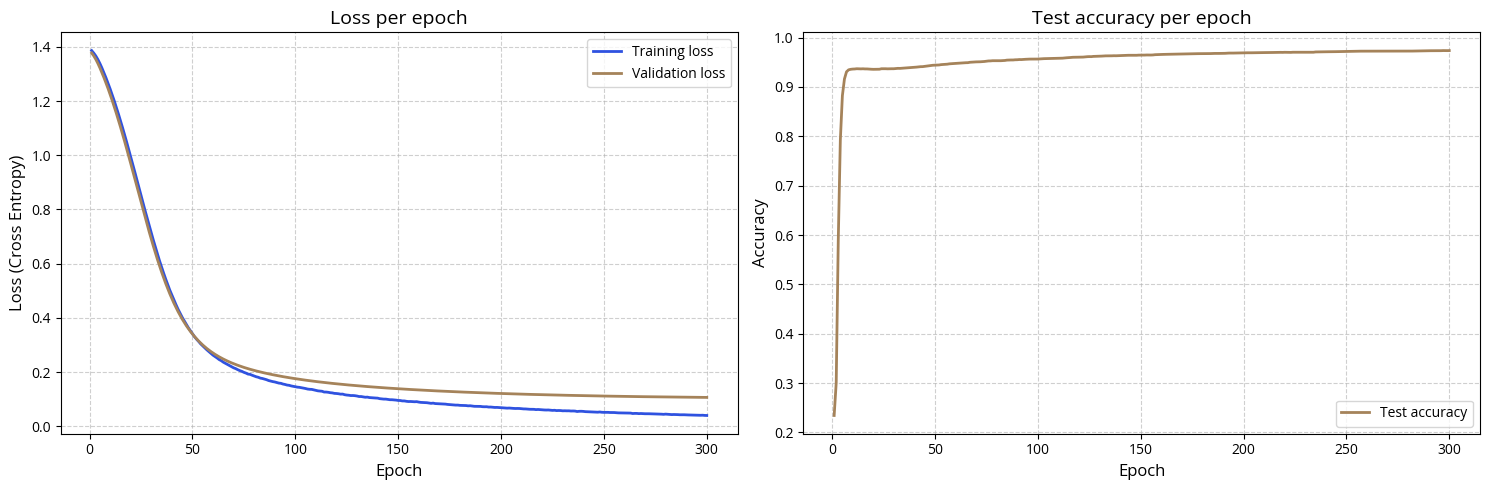

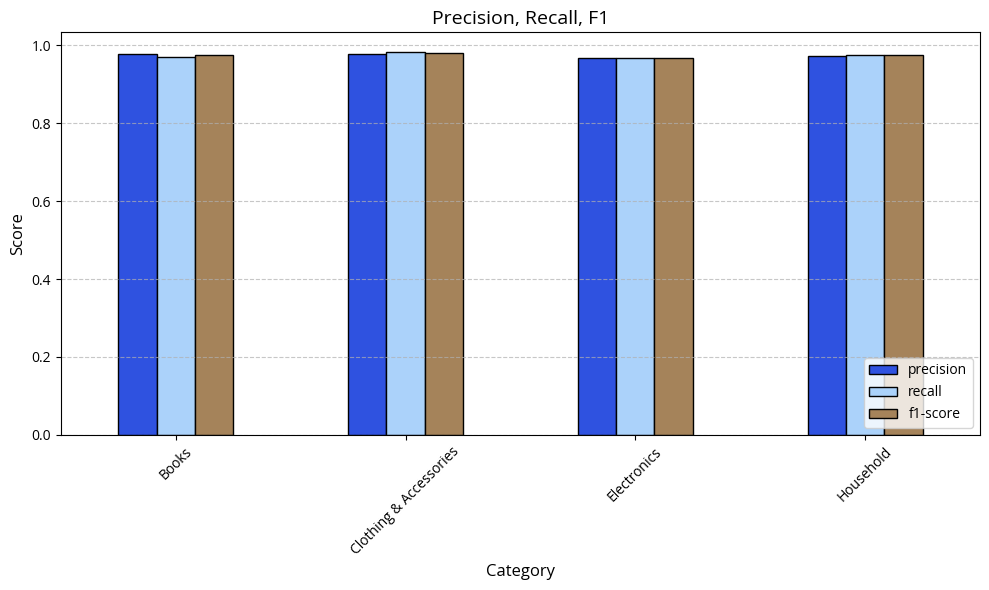

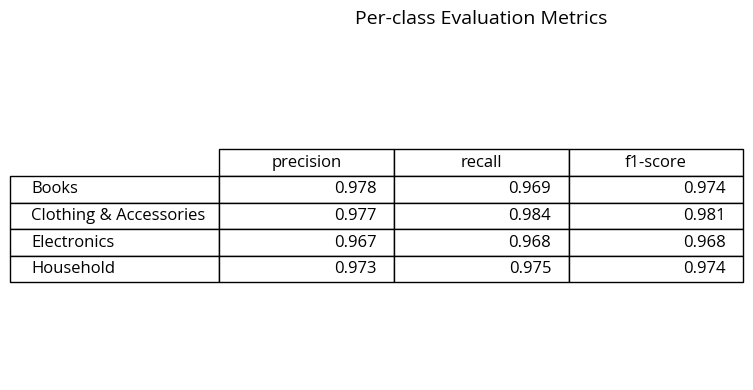

In [3]:
from src.ML.train_NN import TextClassifier

# Simple Feed Forward NN - TF-IDF
X_train, X_test, y_train, y_test, vectorizer = prepare_data(df)

print("Simple Feed Forward NN")

simple_model, class_to_idx, simple_acc = train_model(
    X_train, y_train, X_test, y_test,
    model_class=TextClassifier,
    model_params={"hidden_dim": 256},
    epochs=300,
    lr=0.001
)


Deep Feed Forward NN
Class weights: tensor([1.0665, 1.4538, 1.1869, 0.6528])
Test accuracy: 0.9698
                        precision    recall  f1-score   support

                 Books     0.9722    0.9615    0.9668      2364
Clothing & Accessories     0.9749    0.9844    0.9796      1734
           Electronics     0.9585    0.9666    0.9625      2124
             Household     0.9722    0.9700    0.9711      3863

              accuracy                         0.9698     10085
             macro avg     0.9694    0.9706    0.9700     10085
          weighted avg     0.9698    0.9698    0.9698     10085

Test accuracy: 0.9698


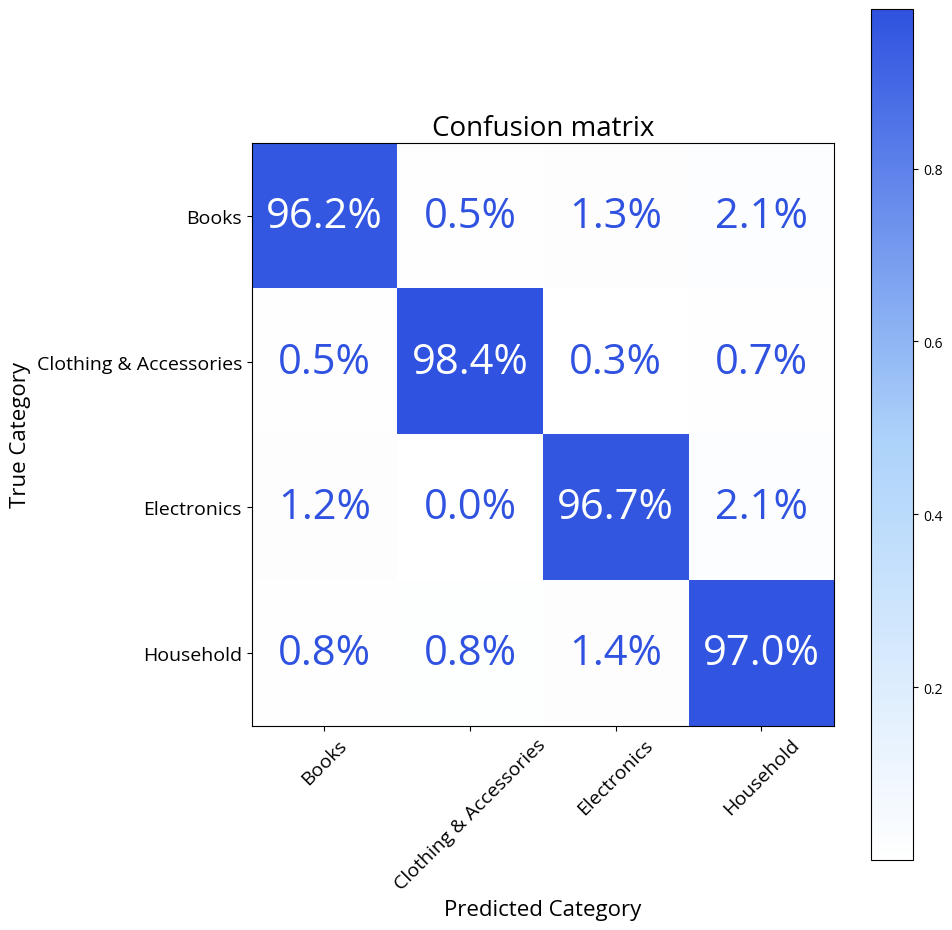

<Figure size 300x200 with 0 Axes>

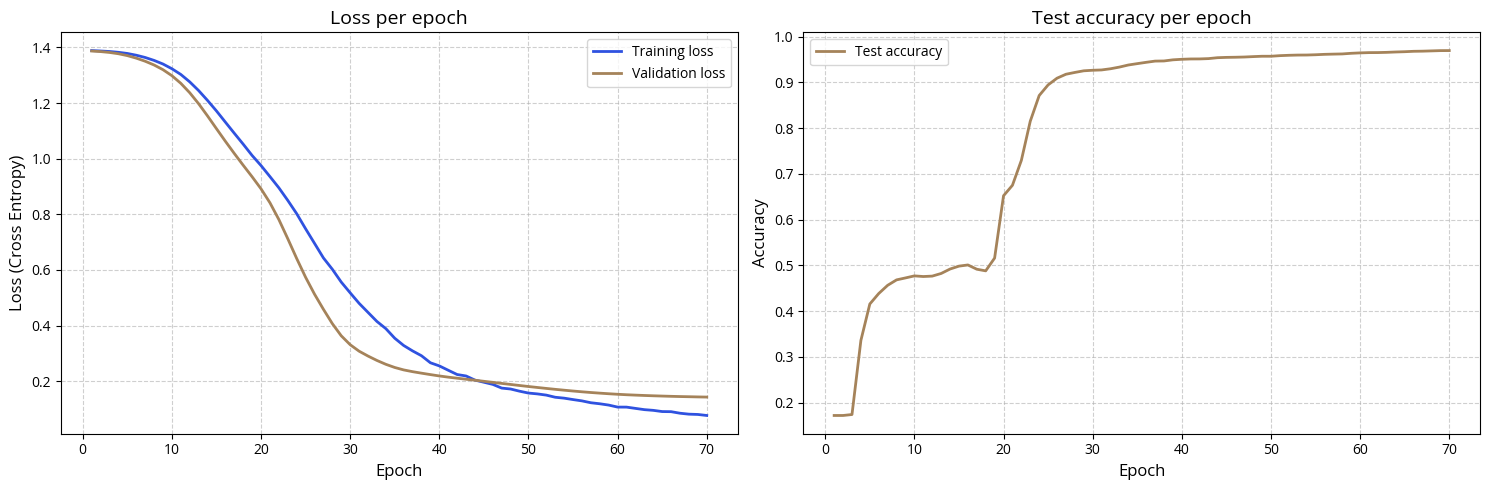

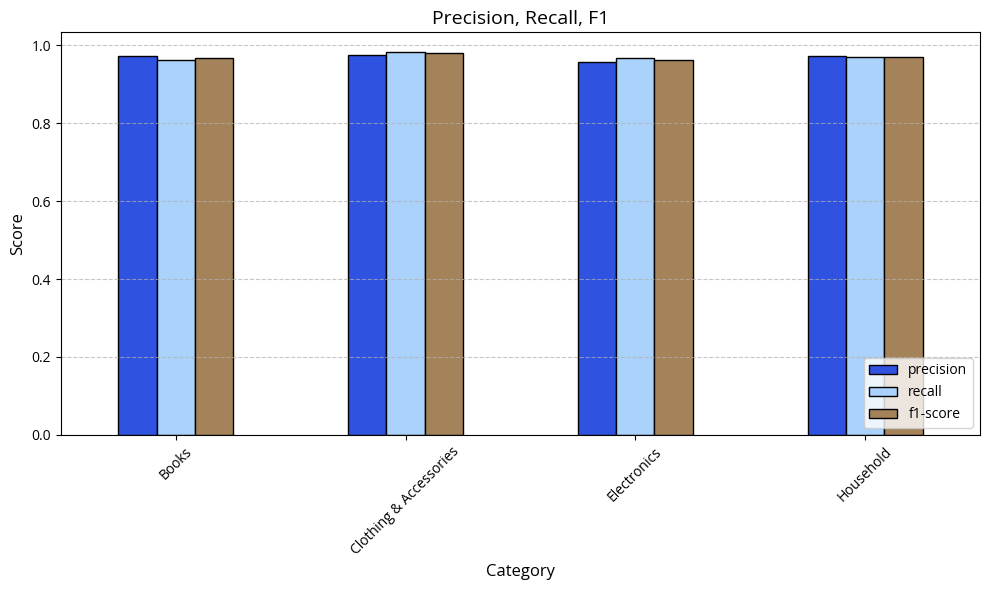

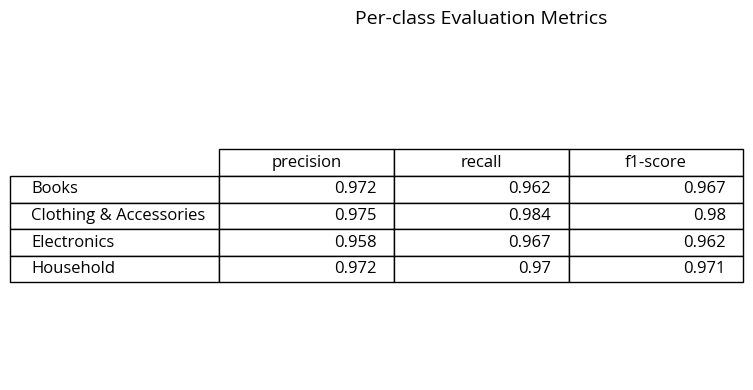

In [4]:
from src.ML.train_NN import DeepTextClassifier

# Deep Feed Forward NN - TF-IDF
X_train, X_test, y_train, y_test, vectorizer = prepare_data(df)

print("Deep Feed Forward NN")

deep_model, class_to_idx, deep_acc = train_model(
    X_train, y_train, X_test, y_test,
    model_class=DeepTextClassifier,
    model_params={"hidden_dims": [512, 256, 128, 64]},
    epochs=70,
    lr=0.001
)


In [5]:
import os
hf_token = os.getenv("HF_TOKEN")

import re

from sklearn.model_selection import train_test_split
import gensim.downloader
from nltk.tokenize import word_tokenize
import nltk     
nltk.download('punkt', quiet=True)

from src.LM.embeddings.embedder_preprocess import clean_text
from src.LM.embeddings.embedder_preprocess import load_word2vec_model
from src.LM.embeddings.embedder_preprocess import text_to_vector
from src.LM.embeddings.embedder_preprocess import prepare_data_word2vec

In [6]:
df = load_data("/home/xkubanova_126831/bakalarka/e_com_dataset/data/ecommerceDataset.csv")
df["Text"] = df["Text"].apply(clean_text)
# load word2vec
w2vmodel = load_word2vec_model()
print("Model loaded. Vector size:", w2vmodel.vector_size) 
print(df["Category"].value_counts(normalize=True))

Dataset shape: (50425, 2)

Categories samples:

Books:
  Inner Engineering: A Yogi's Guide to Joy About the Author Sadhguru Jaggi VasudevSADHGURU is a yogi, mystic, and visionary who established the Isha Foundation, a nonprofit dedicated to the cultivation of human potential. He belongs to no particular tradition, and his scientific methods for self-transformation have universal appeal. Sadhguru has been an in?uential voice at global forums including th...

Clothing & Accessories:
  Woopower 36M Pink for 024M Baby Trouser Top Sets3Pcs Boy Girl Hooded Topsstriped Pantshairband Outfits36Mpink Size name36m colourpink description100 brand new and type children setgender unisexfor season autumn springcoloroptional pink greensize table 7080 90 100cminchsize tops length bust pants length age70 32 1260 46 1811 37 1457 36m80 34 1339 48 1890 39 1535 612m90 36 1417 52 2047 41 1614 1218m...

Electronics:
  Dell 19.5V-3.34AMP 65W Laptop Adapter (Without power Cord) Design Features of Dell Laptop - 

Loading pretrained Word2Vec model from gensim…
Model loaded
Class weights: tensor([1.0665, 1.4538, 1.1869, 0.6528])
Test accuracy: 0.9172
                        precision    recall  f1-score   support

                 Books     0.9425    0.9146    0.9283      2364
Clothing & Accessories     0.9101    0.9573    0.9331      1734
           Electronics     0.8834    0.9025    0.8929      2124
             Household     0.9247    0.9089    0.9167      3863

              accuracy                         0.9172     10085
             macro avg     0.9152    0.9208    0.9177     10085
          weighted avg     0.9176    0.9172    0.9172     10085

Test accuracy: 0.9172


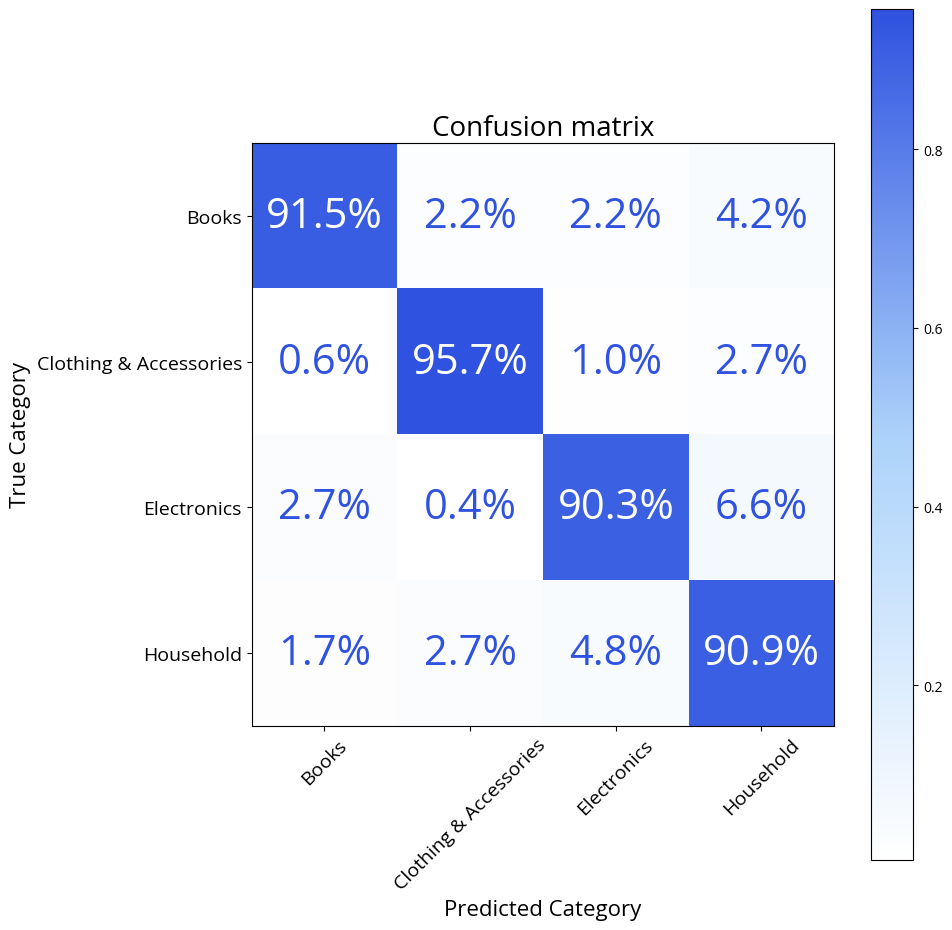

<Figure size 300x200 with 0 Axes>

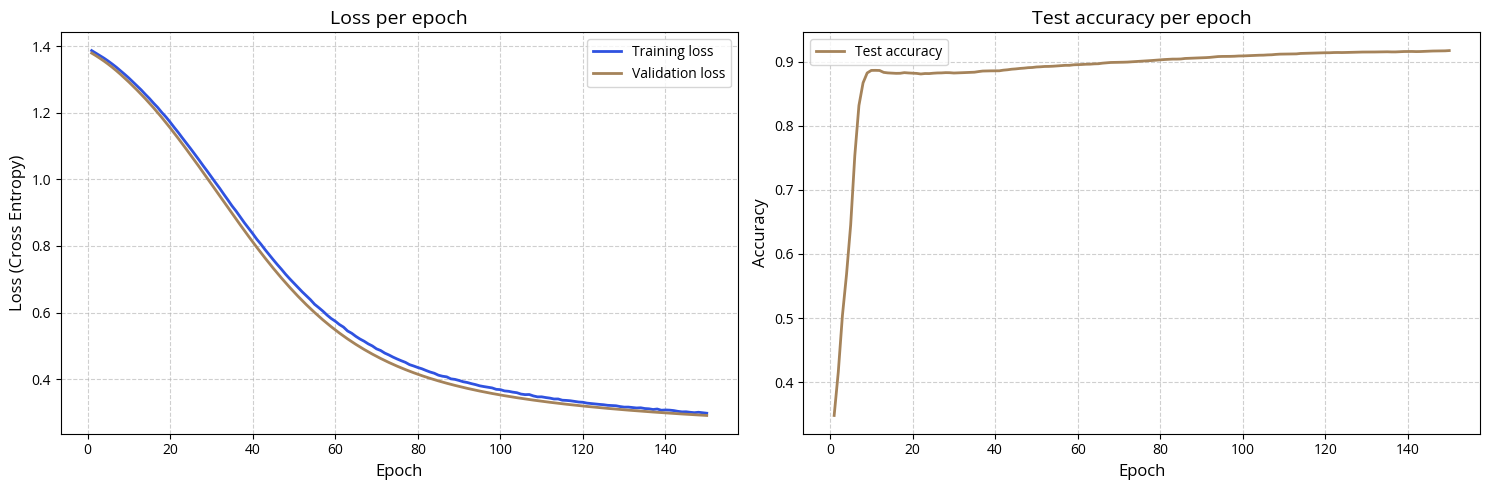

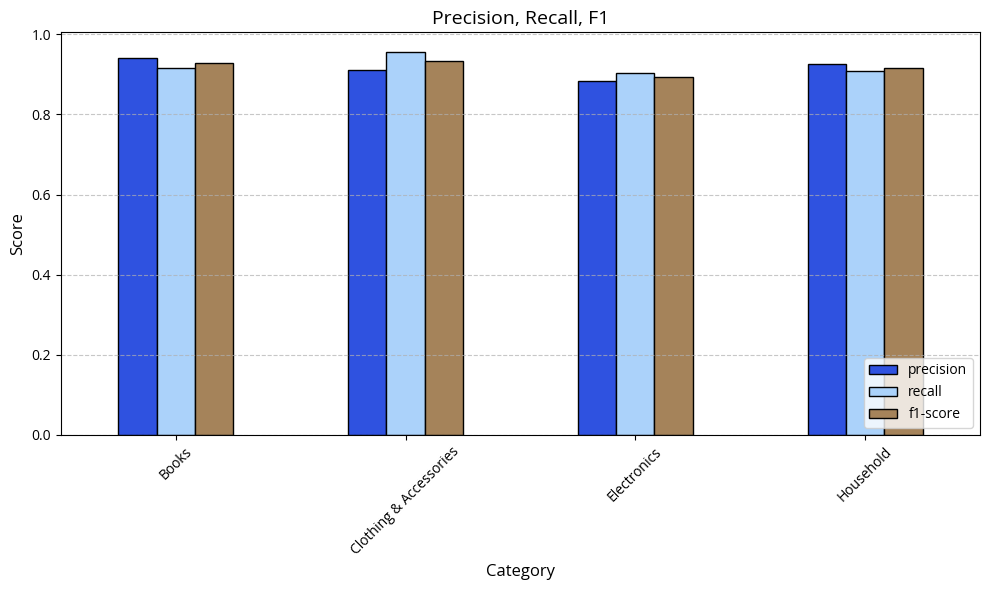

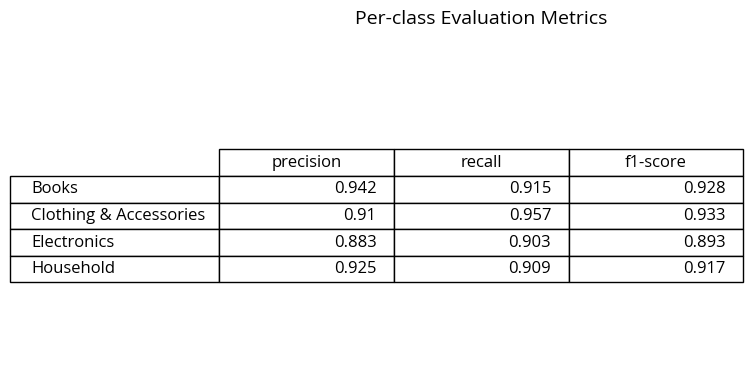

In [7]:
#Simple Feed Forward NN - Word2Vec

X_train_vec, X_test_vec, y_train, y_test, w2v_model = prepare_data_word2vec(df)
model, class_to_idx, acc = train_model(
    X_train_vec, y_train, X_test_vec, y_test,
    model_class=TextClassifier,
    model_params={"hidden_dim": 128},
    epochs=150,
    lr=0.001
)

Loading pretrained Word2Vec model from gensim…
Model loaded
Class weights: tensor([1.0665, 1.4538, 1.1869, 0.6528])
Test accuracy: 0.9426
                        precision    recall  f1-score   support

                 Books     0.9515    0.9463    0.9489      2364
Clothing & Accessories     0.9448    0.9781    0.9612      1734
           Electronics     0.9074    0.9364    0.9217      2124
             Household     0.9565    0.9278    0.9419      3863

              accuracy                         0.9426     10085
             macro avg     0.9401    0.9471    0.9434     10085
          weighted avg     0.9430    0.9426    0.9426     10085

Test accuracy: 0.9426


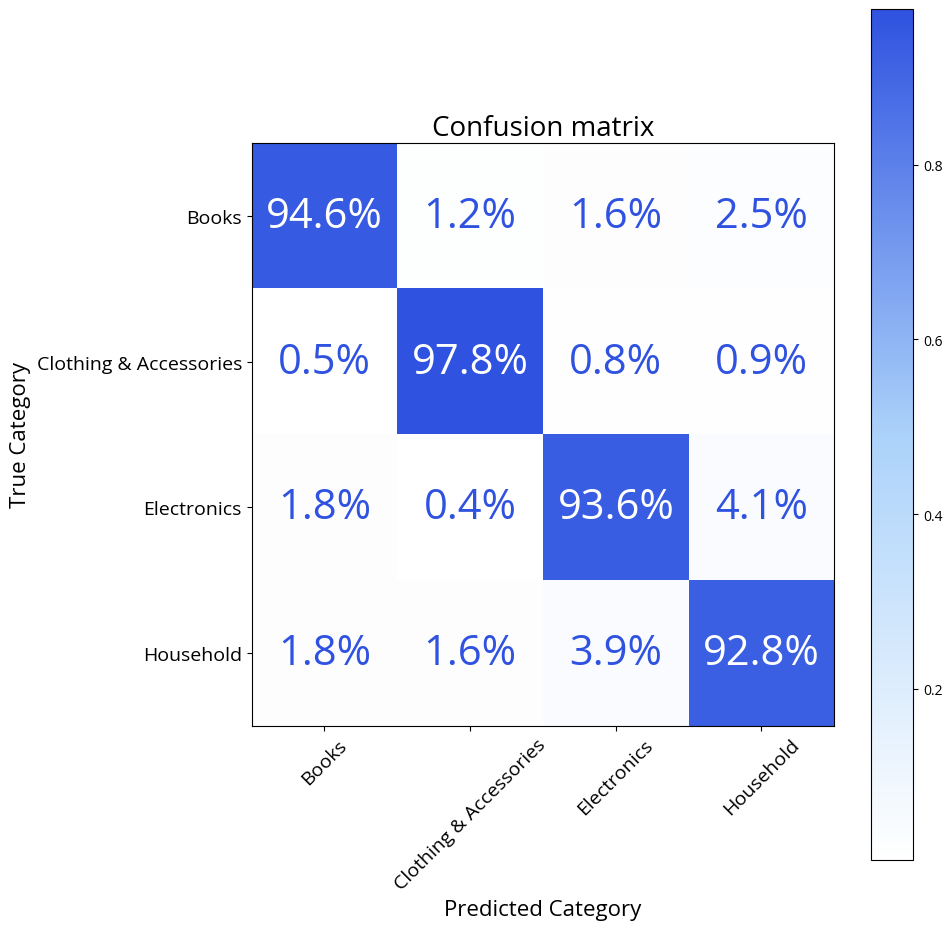

<Figure size 300x200 with 0 Axes>

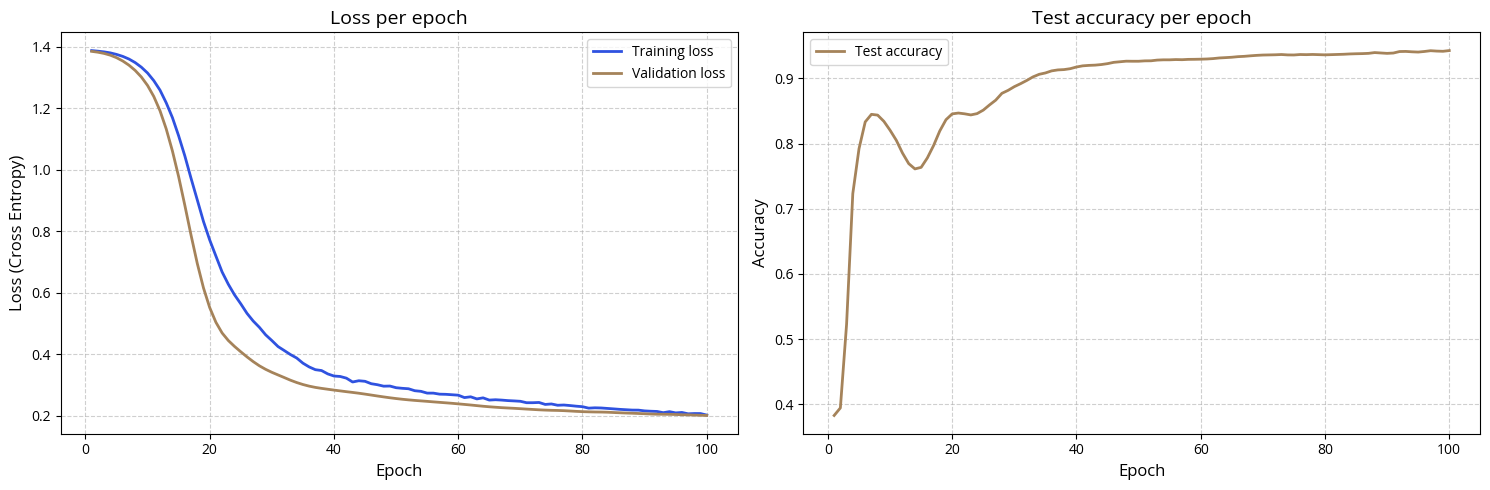

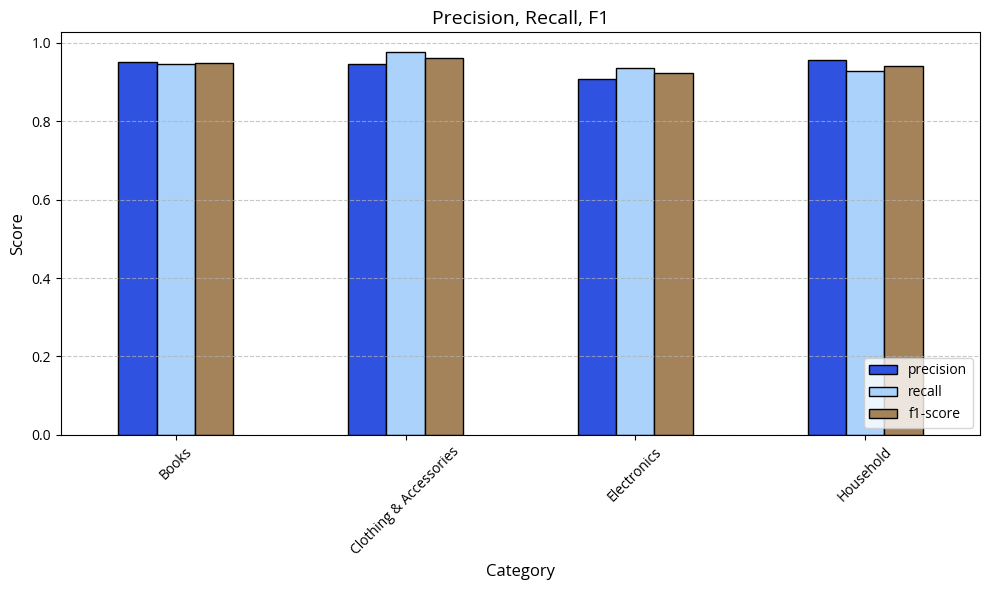

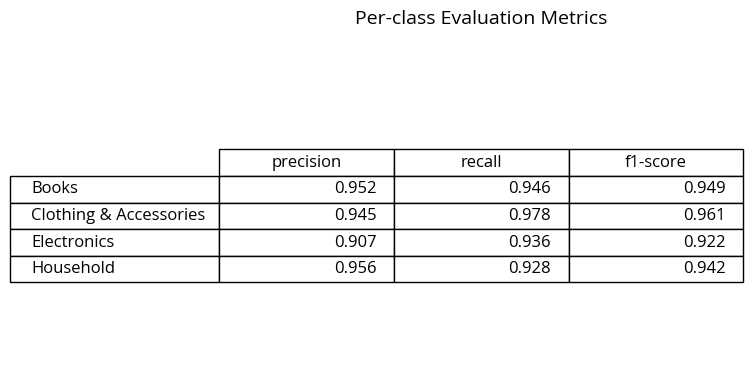

In [8]:
#Deep Feed Forward NN - Word2Vec

X_train_vec, X_test_vec, y_train, y_test, w2v_model = prepare_data_word2vec(df)
model, class_to_idx, acc = train_model(
    X_train_vec, y_train, X_test_vec, y_test,
    model_class=DeepTextClassifier,
    model_params={"hidden_dims": [512, 256, 128, 64]},
    epochs=100,
    lr=0.001
)

In [9]:
from transformers import AutoTokenizer, AutoModel
import torch
from src.LM.embeddings.embedder_preprocess import load_minilm_embedder, prepare_data_minilm
from src.data_loader import load_data
from src.ML.train_NN import train_model


df = load_data("/home/xkubanova_126831/bakalarka/e_com_dataset/data/ecommerceDataset.csv")

print(df["Category"].value_counts(normalize=True))

# MiniLM embedder
device = "cuda"
print('using devide:', device)
tokenizer, minilm_model = load_minilm_embedder("sentence-transformers/all-MiniLM-L6-v2", device=device)
minilm_model.eval()  


X_train_vec, X_test_vec, y_train, y_test = prepare_data_minilm(df, tokenizer, minilm_model, device=device, batch_size = 32)

Dataset shape: (50425, 2)

Categories samples:

Books:
  Inner Engineering: A Yogi's Guide to Joy About the Author Sadhguru Jaggi VasudevSADHGURU is a yogi, mystic, and visionary who established the Isha Foundation, a nonprofit dedicated to the cultivation of human potential. He belongs to no particular tradition, and his scientific methods for self-transformation have universal appeal. Sadhguru has been an in?uential voice at global forums including th...

Clothing & Accessories:
  Woopower 36M Pink for 024M Baby Trouser Top Sets3Pcs Boy Girl Hooded Topsstriped Pantshairband Outfits36Mpink Size name36m colourpink description100 brand new and type children setgender unisexfor season autumn springcoloroptional pink greensize table 7080 90 100cminchsize tops length bust pants length age70 32 1260 46 1811 37 1457 36m80 34 1339 48 1890 39 1535 612m90 36 1417 52 2047 41 1614 1218m...

Electronics:
  Dell 19.5V-3.34AMP 65W Laptop Adapter (Without power Cord) Design Features of Dell Laptop - 

Encoding batches: 100%|██████████| 316/316 [00:02<00:00, 112.94it/s]


Class weights: tensor([1.0665, 1.4538, 1.1869, 0.6528])
Test accuracy: 0.9343
                        precision    recall  f1-score   support

                 Books     0.9434    0.9310    0.9372      2364
Clothing & Accessories     0.9340    0.9706    0.9519      1734
           Electronics     0.9110    0.9200    0.9154      2124
             Household     0.9419    0.9278    0.9348      3863

              accuracy                         0.9343     10085
             macro avg     0.9326    0.9373    0.9348     10085
          weighted avg     0.9344    0.9343    0.9342     10085

Test accuracy: 0.9343


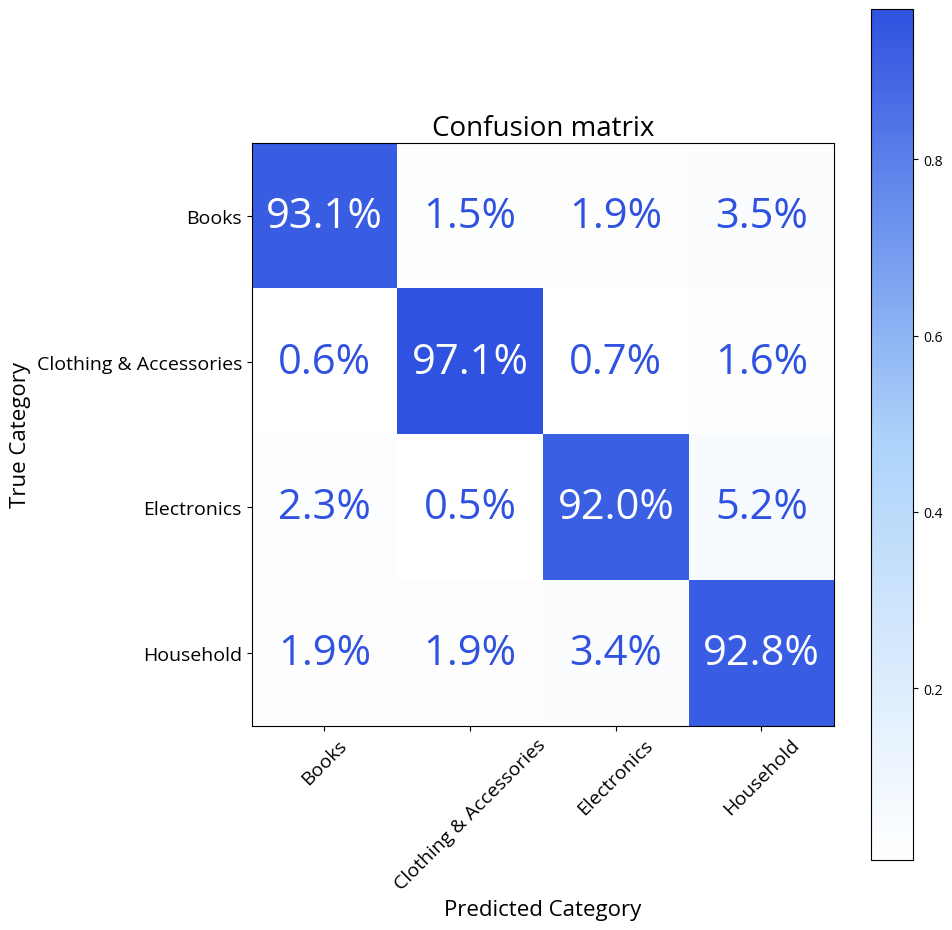

<Figure size 300x200 with 0 Axes>

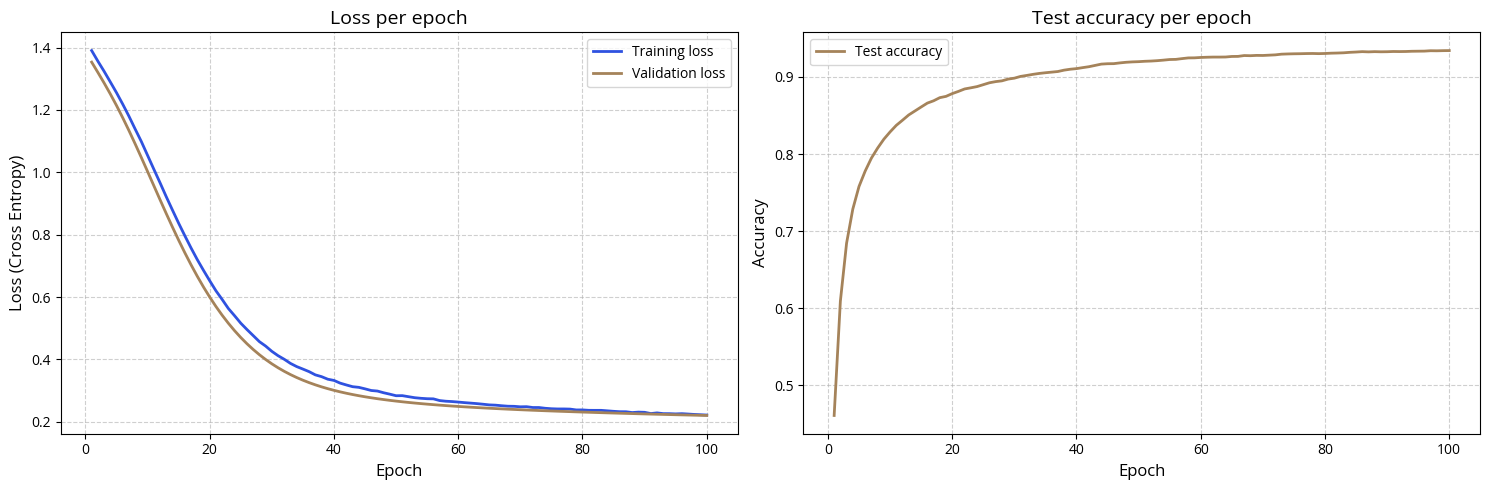

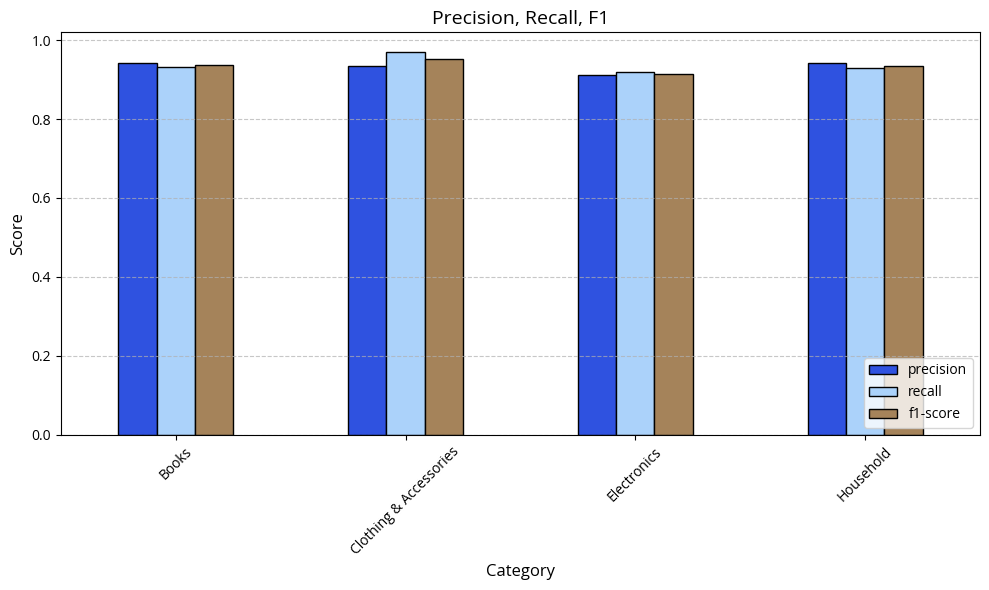

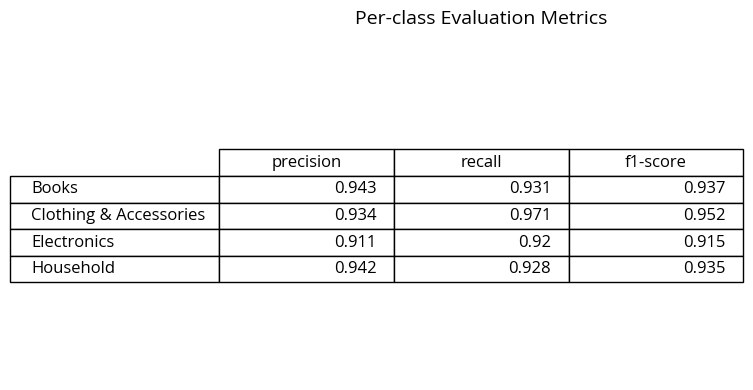

In [10]:
#Simple Feed Forward NN - MiniLM

model, class_to_idx, acc = train_model(
    X_train_vec, y_train, X_test_vec, y_test,
    model_class=TextClassifier,
    model_params={"hidden_dim": 128},
    epochs=100,
    lr=0.001
)


Class weights: tensor([1.0665, 1.4538, 1.1869, 0.6528])
Test accuracy: 0.9618
                        precision    recall  f1-score   support

                 Books     0.9651    0.9581    0.9616      2364
Clothing & Accessories     0.9676    0.9815    0.9745      1734
           Electronics     0.9492    0.9581    0.9536      2124
             Household     0.9643    0.9573    0.9608      3863

              accuracy                         0.9618     10085
             macro avg     0.9615    0.9638    0.9626     10085
          weighted avg     0.9618    0.9618    0.9618     10085

Test accuracy: 0.9618


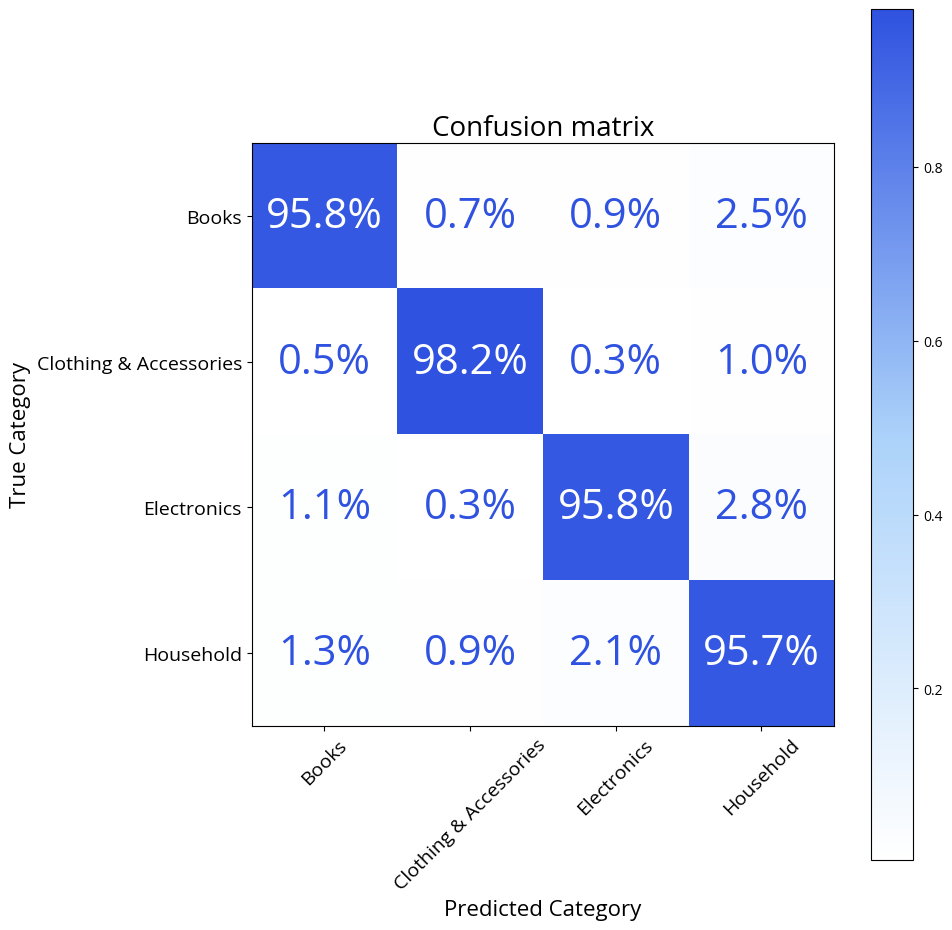

<Figure size 300x200 with 0 Axes>

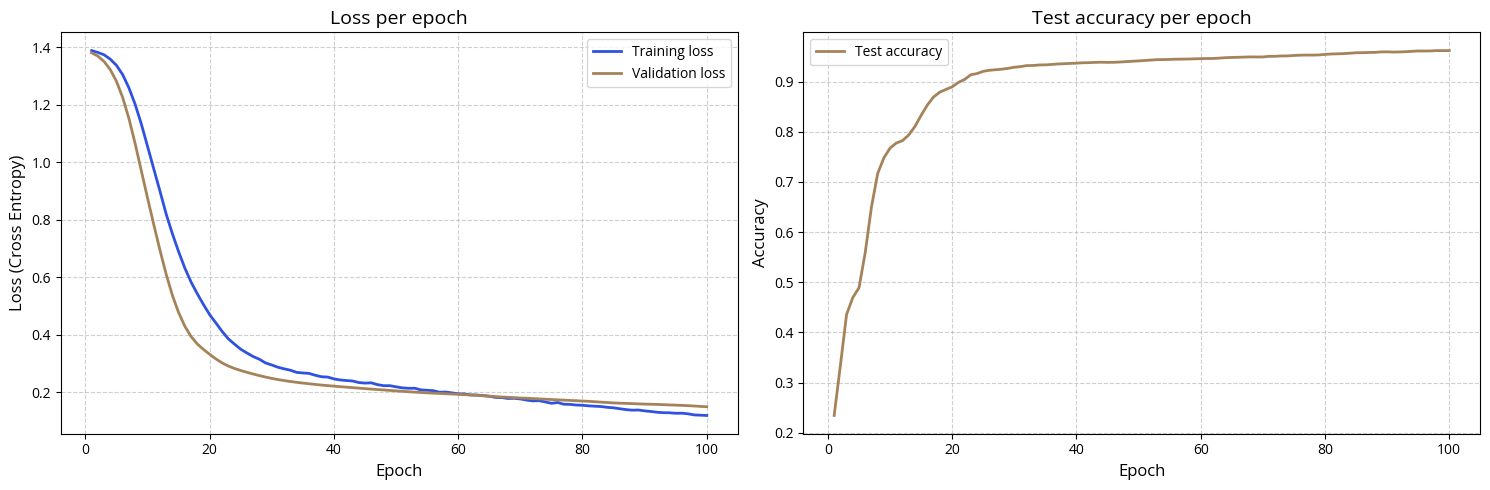

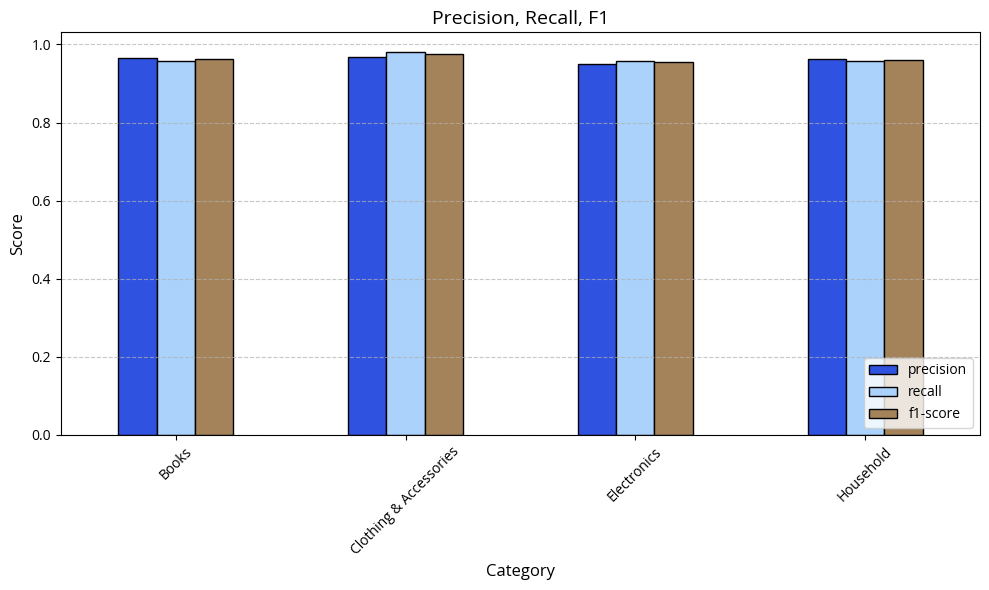

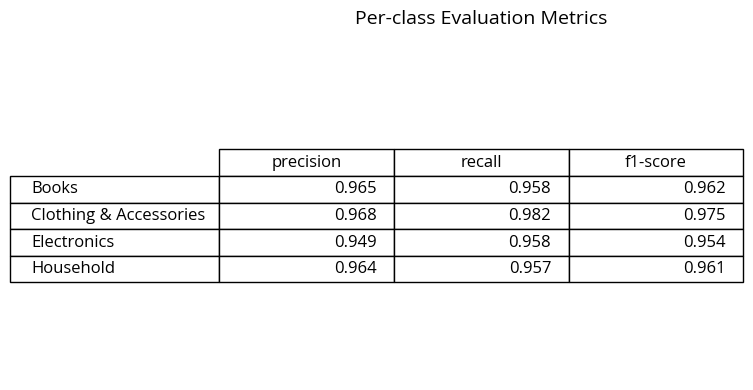

In [11]:
#Deep Feed Forward NN - MiniLM

model, class_to_idx, acc = train_model(
    X_train_vec, y_train, X_test_vec, y_test,
    model_class=DeepTextClassifier,
    model_params={"hidden_dims": [512, 256, 128, 64]},
    epochs=100,
    lr=0.001
)
